# 第4章: 言語解析

問題30から問題35までは、以下の文章`text`（太宰治の『走れメロス』の冒頭部分）に対して、言語解析を実施せよ。問題36から問題39までは、国家を説明した文書群（日本語版ウィキペディア記事から抽出したテキスト群）をコーパスとして、言語解析を実施せよ。

In [1]:
text = """
メロスは激怒した。
必ず、かの邪智暴虐の王を除かなければならぬと決意した。
メロスには政治がわからぬ。
メロスは、村の牧人である。
笛を吹き、羊と遊んで暮して来た。
けれども邪悪に対しては、人一倍に敏感であった。
"""

## 30. 動詞
文章`text`に含まれる動詞をすべて表示せよ。

In [2]:
!pip install janome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 56.0 MB/s eta 0:00:00


In [3]:
from janome.tokenizer import Tokenizer

t = Tokenizer()

# 文章を単語ごとに分割して品詞を確認する
for token in t.tokenize(text):
  res = token.part_of_speech.split(",")

  if (res[0] == "動詞"):
    print(token.surface)

し
除か
なら
し
わから
吹き
遊ん
暮し
来


## 31. 動詞の原型
文章`text`に含まれる動詞と、その原型をすべて表示せよ。

In [4]:
for token in t.tokenize(text):
  res = token.part_of_speech.split(",")

  if (res[0] == "動詞"):
    print(token.base_form)

する
除く
なる
する
わかる
吹く
遊ぶ
暮す
来る


## 32. 「AのB」
文章`text`において、2つの名詞が「の」で連結されている名詞句をすべて抽出せよ。

In [5]:
data = t.tokenize(text)
res = []

for i,token in enumerate(data):
  part_of_speech = token.part_of_speech.split(",")[0]
  res.append([token.surface, part_of_speech])

  if (len(res) >= 3):

    if (res[1][0] == "の"):
      if (res[0][1] == "名詞") and (res[2][1] == "名詞"):
        print(res[0][0])
        print(res[2][0])

    del res[0]

暴虐
王
村
牧人


## 33. 係り受け解析

文章`text`に係り受け解析を適用し、係り元と係り先のトークン（形態素や文節などの単位）をタブ区切り形式ですべて抽出せよ。

In [6]:
!pip install -U ginza ja-ginza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.1 MB/s eta 0:00:00


In [7]:
import spacy

# エラーを回避するための設定（config）を定義
config = {
    "components": {
        "compound_splitter": {
            "split_mode": "C",
        }
    }
}

# configを渡してGiNZA（日本語モデル）を読み込む
nlp = spacy.load("ja_ginza", config=config)

In [8]:
# 2. 解析したいテキストを渡す
doc = nlp(text.replace("\n", ""))

# 3. 係り受けの結果を1単語ずつ取り出して表示する
for token in doc:
    # token.text      : その単語（係り元）
    # token.head.text : どこにかかっているか（係り先）
    # token.dep_      : どういう関係か（主語、目的語など）
    print(f"{token.text} -> {token.head.text} ({token.dep_})")

メロス -> 激怒 (nsubj)
は -> メロス (case)
激怒 -> 激怒 (ROOT)
し -> 激怒 (aux)
た -> 激怒 (aux)
。 -> 激怒 (punct)
必ず -> 除か (advmod)
、 -> 必ず (punct)
かの -> 暴虐 (det)
邪智 -> 暴虐 (compound)
暴虐 -> 王 (nmod)
の -> 暴虐 (case)
王 -> 除か (obj)
を -> 王 (case)
除か -> 決意 (advcl)
なけれ -> 除か (aux)
ば -> なけれ (fixed)
なら -> なけれ (fixed)
ぬ -> なけれ (fixed)
と -> 除か (case)
決意 -> 決意 (ROOT)
し -> 決意 (aux)
た -> 決意 (aux)
。 -> 決意 (punct)
メロス -> わから (obl)
に -> メロス (case)
は -> メロス (case)
政治 -> わから (nsubj)
が -> 政治 (case)
わから -> わから (ROOT)
ぬ -> わから (aux)
。 -> わから (punct)
メロス -> 牧人 (nsubj)
は -> メロス (case)
、 -> メロス (punct)
村 -> 牧人 (nmod)
の -> 村 (case)
牧人 -> 牧人 (ROOT)
で -> 牧人 (cop)
ある -> で (fixed)
。 -> 牧人 (punct)
笛 -> 吹き (obj)
を -> 笛 (case)
吹き -> 暮し (advcl)
、 -> 吹き (punct)
羊 -> 遊ん (obl)
と -> 羊 (case)
遊ん -> 暮し (advcl)
で -> 遊ん (mark)
暮し -> 暮し (ROOT)
て -> 暮し (mark)
来 -> て (fixed)
た -> 暮し (aux)
。 -> 暮し (punct)
けれど -> 敏感 (cc)
も -> けれど (fixed)
邪悪 -> 敏感 (obl)
に -> 邪悪 (case)
対し -> に (fixed)
ては -> に (fixed)
、 -> 邪悪 (punct)
人 -> 倍 (compound)
一 -> 倍 (nummod)
倍 ->

## 34. 主述の関係
文章`text`において、「メロス」が主語であるときの述語を抽出せよ。

In [9]:
# 2. 解析したいテキストを渡す
doc = nlp(text.replace("\n", ""))

# 3. 係り受けの結果を1単語ずつ取り出して表示する
for token in doc:
    if (token.dep_ == "nsubj") and (token.text == "メロス"):
      print(token.head.text)

激怒
牧人


## 35. 係り受け木
「メロスは激怒した。」の係り受け木を可視化せよ。

In [10]:
from spacy import displacy

text = "メロスは激怒した。"
doc = nlp(text)

displacy.render(doc,
                style="dep"   # 描画スタイルの指定　dep -> 係り受け
                )

## 36. 単語の出現頻度

問題36から39までは、Wikipediaの記事を以下のフォーマットで書き出したファイル[jawiki-country.json.gz](/data/jawiki-country.json.gz)をコーパスと見なし、統計的な分析を行う。

* 1行に1記事の情報がJSON形式で格納される
* 各行には記事名が"title"キーに、記事本文が"text"キーの辞書オブジェクトに格納され、そのオブジェクトがJSON形式で書き出される
* ファイル全体はgzipで圧縮される

まず、第3章の処理内容を参考に、Wikipedia記事からマークアップを除去し、各記事のテキストを抽出せよ。そして、コーパスにおける単語（形態素）の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [11]:
!pip install mecab-python3 unidic-lite

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 15.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 9.2 MB/s eta 0:00:00
  Created wheel for unidic-lite: filename=unidic_lite-1.0.8-py3-none-any.whl size=47658817 sha256=2b257b9b689d15285e0b6f09c6aef3c02652c5b8653ff7c00f15997ffcd0c09d
  Stored in directory: /root/.cache/pip/wheels/5e/1f/0f/4d43887e5476d956fae828ee9b6687becd5544d68b51ed633d
Successfully built unidic-lite


In [12]:
import re
import json

import MeCab
from collections import Counter

In [26]:
word_counts = Counter()
t = Tokenizer()

pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

with open("jawiki-country.json", 'r') as f:
  for line in f:
      line = json.loads(line)["text"]
      data = t.tokenize(line)

      for word in data:
        res = word.part_of_speech.split(",")
        pos = res[0]
        original = word.base_form

        if ((pos in ["名詞", "動詞", "形容詞"]) and (bool(pattern.search(original)) == True)):
          word_counts[(original, pos)] += 1

for i, ((word, pos), count) in enumerate(word_counts.most_common(20), 1):
    print(f"{i}: {word} ({count}回)")

1: する (48174回)
2: 年 (30229回)
3: れる (18574回)
4: いる (17519回)
5: 月 (13705回)
6: 日 (10508回)
7: 人 (10135回)
8: 国 (9082回)
9: なる (7570回)
10: ある (5835回)
11: 語 (5803回)
12: 的 (5263回)
13: 世界 (4819回)
14: こと (4642回)
15: リンク (4414回)
16: 日本 (4343回)
17: 大統領 (4056回)
18: 政府 (3646回)
19: ため (3551回)
20: 州 (3440回)


## 37. 名詞の出現頻度
コーパスにおける名詞の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [29]:
i = 1
for ((word, pos), count) in word_counts:

  if (pos == "名詞"):
    print(f"{i}: {word} ({count}回)")
    i += 1

  if (i > 20):
    break

1: 年 (30229回)
2: 月 (13705回)
3: 日 (10508回)
4: 人 (10135回)
5: 国 (9082回)
6: 語 (5803回)
7: 的 (5263回)
8: 世界 (4819回)
9: こと (4642回)
10: リンク (4414回)
11: 日本 (4343回)
12: 大統領 (4056回)
13: 政府 (3646回)
14: ため (3551回)
15: 州 (3440回)


## 38. TF・IDF
日本に関する記事における名詞のTF・IDFスコアを求め、TF・IDFスコア上位20語とそのTF, IDF, TF・IDFを表示せよ。

In [34]:
import math

In [60]:
t = Tokenizer()

japan = {}
others = {}
dic38 = {}
total_docs = 0

pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

with open("jawiki-country.json", 'r') as f:
  for line in f:
      line = json.loads(line)
      total_docs += 1

      data = t.tokenize(line["text"])

      if (line["title"] == "日本"):
        dic38 = japan
      else:
        dic38 = others
        data = set(data)


      for word in data:
        res = word.part_of_speech.split(",")
        pos = res[0]
        original = word.surface

        if ((pos == "名詞") and (bool(pattern.search(original)) == True)):
          if (original in dic38):
            dic38[original] += 1
          else:
            dic38[original] = 1

tf_idf_score = []

tf_idf_score = []

for i, word in enumerate(japan, 1):
  count = japan[word]

  tf = count / len(japan)

  doc_count = 0
  if (word in others):
    doc_count = others[word]
  else:
    doc_count = 1

  idf = math.log(total_docs / doc_count)
  tf_idf_score.append((tf, idf, tf * idf, word))

tf_idf_score.sort(reverse=True)

print("wrod\tTF-score\tIDF-dcore\tTF・IDF-score")
for i in range(20):
  print(f"{tf_idf_score[0]}:\t{tf_idf_score[1]:.4f}\t{tf_idf_score[2]:.4f}\t{tf_idf_score[3]:.4f}")

琉球, 0.04322347171453584
倭国, 0.039551138781671324
倭, 0.030702436646179814
日本書紀, 0.02669701867762814
沖縄, 0.02390978132278411
天皇, 0.0215724976908059
所蔵, 0.020585586064368486
九州大学, 0.019775569390835662
アイヌ, 0.019775569390835662
北陸, 0.01878679092129388
列島, 0.018337730416094114
南西諸島, 0.017798012451752096
都道府県, 0.017023689177911965
奄美, 0.016626819513528394
神武, 0.01582045551266853
ヤマト, 0.01582045551266853
新幹線, 0.015043312893192357
にっぽん, 0.014831677043126747
北海道, 0.014773497707247176
唐, 0.014282403654403659


## 39. Zipfの法則
コーパスにおける単語の出現頻度順位を横軸、その出現頻度を縦軸として、両対数グラフをプロットせよ。

Counter()
[]


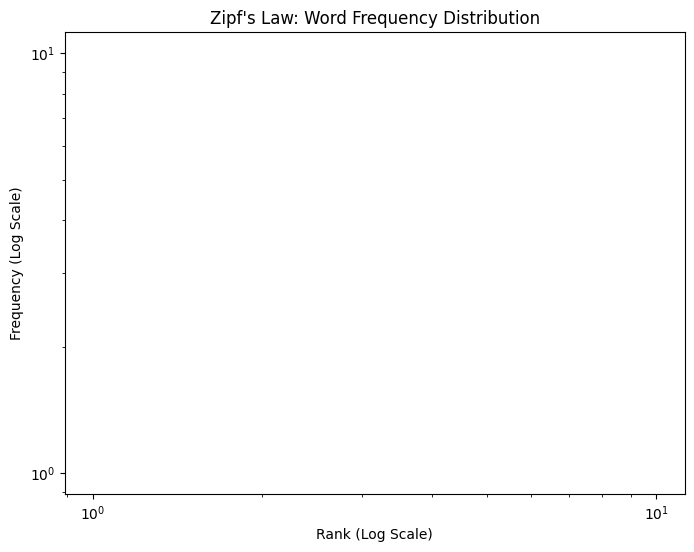

In [62]:
import matplotlib.pyplot as plt

# --- 1. word_counts からグラフ用のデータを抽出する ---

# most_common() を使うと出現頻度順（降順）に並んだデータが取得できるので、
# そこから「頻度（count）」の数値だけをリストとして取り出します。
# ※キーが (単語, 品詞) のタプルでも、ここでは数値しか使わないので問題ありません。
frequencies = [count for item, count in word_counts.most_common()]
print(word_counts)
print(frequencies)

# 順位（Rank）のリストを作ります。1位から始まり、単語の種類数まで連番を作ります。
ranks = range(1, len(frequencies) + 1)


# --- 2. グラフの描画 ---

# グラフのサイズを設定
plt.figure(figsize=(8, 6))

# 両対数グラフのプロット
# plt.loglog() を使うと、自動的にX軸とY軸が対数スケールになります。
# linestyle='None' と marker='.' で、線ではなく点でプロットして見やすくします。
plt.loglog(ranks, frequencies, color='b')

# グラフのタイトルと軸ラベルを設定
# （※matplotlibはデフォルトだと日本語が文字化けするため、英語で設定しています）
plt.title("Zipf's Law: Word Frequency Distribution")
plt.xlabel("Rank (Log Scale)")
plt.ylabel("Frequency (Log Scale)")


# グラフを画面に表示
plt.show()